#  Resume Classification
## Recruitment NLP Lab — Step 5: Classifying Resumes with Neural Networks

This notebook trains **two feedforward neural networks (MLP)**:

1. **Category Classifier** — classifies resumes into one of 4 job domains
2. **Experience Level Classifier** — classifies resumes into one of 4 experience levels

**Data confirmed from previous notebooks:**
- 466 resumes across 4 categories (HR: 110, ACCOUNTANT: 118, ENGINEERING: 118, IT: 120)
- TF-IDF matrix: 466 × 5,000 saved in `data/processed/`
- No experience level column exists -> auto-assigned using regex + word count fallback

**Neural Network Architecture (both models):**
- Input layer   : 5,000 neurons (TF-IDF features)
- Hidden layer 1: 512 neurons, ReLU + BatchNorm + Dropout(0.4)
- Hidden layer 2: 256 neurons, ReLU + BatchNorm + Dropout(0.3)
- Hidden layer 3: 128 neurons, ReLU + Dropout(0.2)
- Output layer  : 4 neurons, Softmax

### Add Python 3.11 as a kernel

In [3]:
!py -3.11 -m pip install ipykernel
!py -3.11 -m ipykernel install --user --name py311 --display-name "Python 3.11"


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Installed kernelspec py311 in C:\Users\Dell\AppData\Roaming\jupyter\kernels\py311


In [1]:
import sys
print(sys.executable)

C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe


##  1. Install & Import Libraries

In [3]:
!py -3.11 -m pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

                                              0.0/294.9 kB ? eta -:--:--
     -                                        10.2/294.9 kB ? eta -:--:--
     ---                                   30.7/294.9 kB 330.3 kB/s eta 0:00:01
     -------                               61.4/294.9 kB 365.7 kB/s eta 0:00:01
     -----------                           92.2/294.9 kB 403.5 kB/s eta 0:00:01
     -----------------                    143.4/294.9 kB 448.2 kB/s eta 0:00:01
     ----------------------               184.3/294.9 kB 484.9 kB/s eta 0:00:01
     ----------------------------         235.5/294.9 kB 554.9 kB/s eta 0:00:01
     ----------------------------         235.5/294.9 kB 554.9 kB/s eta 0:00:01
     ------------------------------------ 294.9/294.9 kB 588.2 kB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
import os
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

os.makedirs("../results/plots",   exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/models",  exist_ok=True)

print(f"   All libraries imported!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   NumPy version      : {np.__version__}")

   All libraries imported!
   TensorFlow version : 2.20.0
   NumPy version      : 2.4.2


##  2. Load Saved TF-IDF Data

Loading the TF-IDF matrix and labels saved from `03_keyword_extraction.ipynb`.
No reprocessing needed — everything is ready to use directly.

In [33]:
# Load TF-IDF matrix
X_sparse = sp.load_npz("../data/processed/resume_tfidf_matrix.npz")

# Convert to dense for Keras
X_dense = X_sparse.toarray()

# Load labels
labels_df = pd.read_csv("../data/processed/resume_labels.csv")
y_raw = labels_df['Category'].values

print(f"   TF-IDF matrix loaded  -> shape : {X_dense.shape}")
print(f"   Labels loaded         -> {len(y_raw)} labels")
print(f"\nCategory distribution:")
print(pd.Series(y_raw).value_counts())

   TF-IDF matrix loaded  -> shape : (466, 5000)
   Labels loaded         -> 466 labels

Category distribution:
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
ACCOUNTANT                118
HR                        110
Name: count, dtype: int64


##  3. Define Neural Network Architecture

A reusable `build_model()` function used for both classifiers.

**Design choices:**
- `BatchNormalization` stabilizes training with small dataset (466 samples)
- `Dropout` prevents overfitting
- `EarlyStopping` stops training when validation loss stops improving

In [65]:
def build_model(input_dim, num_classes):
    """
    Builds a feedforward MLP classifier.
    Args:
        input_dim  : number of input features (5000 for TF-IDF)
        num_classes: number of output classes
    Returns:
        Compiled Keras model
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Hidden layer 2
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden layer 3
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("   build_model() function defined!")

   build_model() function defined!


##  4. Category Classifier — Label Encoding & Data Split

Converting string category labels to one-hot encoded vectors.
Using stratified split to maintain category balance across all sets:
- **80%** Training (≈373 samples)
- **10%** Validation (≈47 samples)
- **10%** Test (≈46 samples)

In [66]:
# Encode category labels
cat_encoder = LabelEncoder()
y_cat_encoded = cat_encoder.fit_transform(y_raw)
y_cat_onehot  = keras.utils.to_categorical(y_cat_encoded, num_classes=4)

print(f"  Category labels encoded!")
print(f"\nLabel mapping:")
for idx, cls in enumerate(cat_encoder.classes_):
    print(f"   {cls:<30} -> {idx}")

# Save encoder
with open("../data/processed/label_encoder.pkl", "wb") as f:
    pickle.dump(cat_encoder, f)
print(f"\n  Category encoder saved!")

  Category labels encoded!

Label mapping:
   ACCOUNTANT                     -> 0
   ENGINEERING                    -> 1
   HR                             -> 2
   INFORMATION-TECHNOLOGY         -> 3

  Category encoder saved!


In [67]:
# Train / Val / Test split — Category
X_train, X_temp, y_train, y_temp = train_test_split(
    X_dense, y_cat_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_cat_encoded
)

y_temp_encoded = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_encoded
)

print(f"   Category data split:")
print(f"   Training   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_dense)*100:.0f}%)")
print(f"   Validation : {X_val.shape[0]} samples ({X_val.shape[0]/len(X_dense)*100:.0f}%)")
print(f"   Test       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_dense)*100:.0f}%)")

   Category data split:
   Training   : 372 samples (80%)
   Validation : 47 samples (10%)
   Test       : 47 samples (10%)


##  5. Train Category Classifier

Training with callbacks:
- `EarlyStopping` — stops if val_loss doesn't improve for 10 epochs
- `ReduceLROnPlateau` — halves learning rate if stuck for 5 epochs
- `ModelCheckpoint` — saves best model weights automatically

In [68]:
cat_model = build_model(input_dim=5000, num_classes=4)
cat_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 512)                 │       2,560,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,728,324 (10.41 MB)

 Trainable params: 2,726,788 (10.40 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [69]:
# Callbacks
cat_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='../results/models/best_category_classifier.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

# Train
cat_history = cat_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=cat_callbacks,
    verbose=1
)

print(f"\n   Category classifier training complete!")
print(f"   Epochs run : {len(cat_history.history['loss'])}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5135 - loss: 1.2284
Epoch 1: val_accuracy improved from None to 0.74468, saving model to ../results/models/best_category_classifier.keras

Epoch 1: finished saving model to ../results/models/best_category_classifier.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.6774 - loss: 0.8371 - val_accuracy: 0.7447 - val_loss: 1.3187 - learning_rate: 0.0010
Epoch 2/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9485 - loss: 0.1377
Epoch 2: val_accuracy did not improve from 0.74468
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9597 - loss: 0.1369 - val_accuracy: 0.7447 - val_loss: 1.2742 - learning_rate: 0.0010
Epoch 3/100
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9637 - loss: 0.0975
Epoch 3: val_accuracy improved from 0.74468 to 0.78723, saving model to ../results/models/best_category_classifier.keras

Epoch 3: finished saving model to ../results/models/best_category_classifier.keras
12/

### 5.1 Training History — Category Classifier

Plotting loss and accuracy curves.
- Curves close together -> good generalization
- Val loss rising while train falls -> overfitting

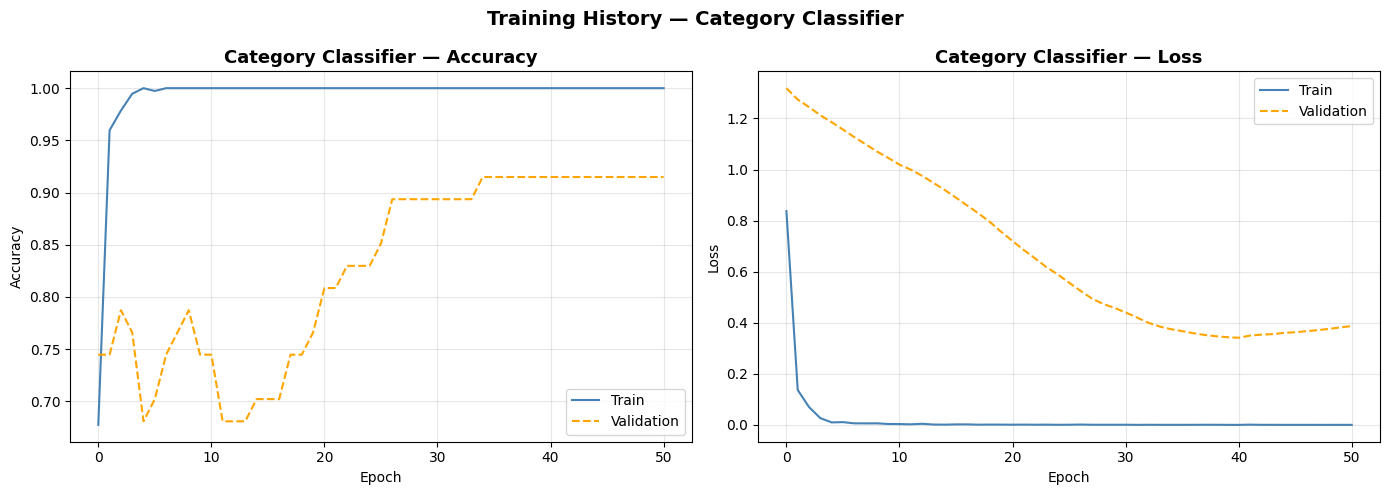

   Plot saved!


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cat_history.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(cat_history.history['val_accuracy'], label='Validation', color='orange', linestyle='--')
axes[0].set_title('Category Classifier — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cat_history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(cat_history.history['val_loss'], label='Validation', color='orange', linestyle='--')
axes[1].set_title('Category Classifier — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Category Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/cat_training_history.png", dpi=150)
plt.show()
print("   Plot saved!")

### 5.2 Evaluate Category Classifier on Test Set

In [71]:
best_cat_model = keras.models.load_model(
    '../results/models/best_category_classifier.keras'
)

cat_loss, cat_acc = best_cat_model.evaluate(X_test, y_test, verbose=0)
print(f"   Category Classifier — Test Results:")
print(f"   Test Loss     : {cat_loss:.4f}")
print(f"   Test Accuracy : {cat_acc*100:.2f}%")

# Predictions
y_cat_pred = np.argmax(best_cat_model.predict(X_test), axis=1)
y_cat_true = np.argmax(y_test, axis=1)

# Classification report
cat_report = classification_report(
    y_cat_true, y_cat_pred,
    target_names=cat_encoder.classes_
)
print(f"\nClassification Report:\n{cat_report}")

with open("../results/metrics/category_classification_report.txt", "w") as f:
    f.write(f"Test Accuracy: {cat_acc*100:.2f}%\n\n")
    f.write(cat_report)
print("   Report saved!")

   Category Classifier — Test Results:
   Test Loss     : 0.3024
   Test Accuracy : 89.36%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       1.00      0.83      0.91        12
           ENGINEERING       0.91      0.83      0.87        12
                    HR       1.00      0.91      0.95        11
INFORMATION-TECHNOLOGY       0.75      1.00      0.86        12

              accuracy                           0.89        47
             macro avg       0.91      0.89      0.90        47
          weighted avg       0.91      0.89      0.90        47

   Report saved!


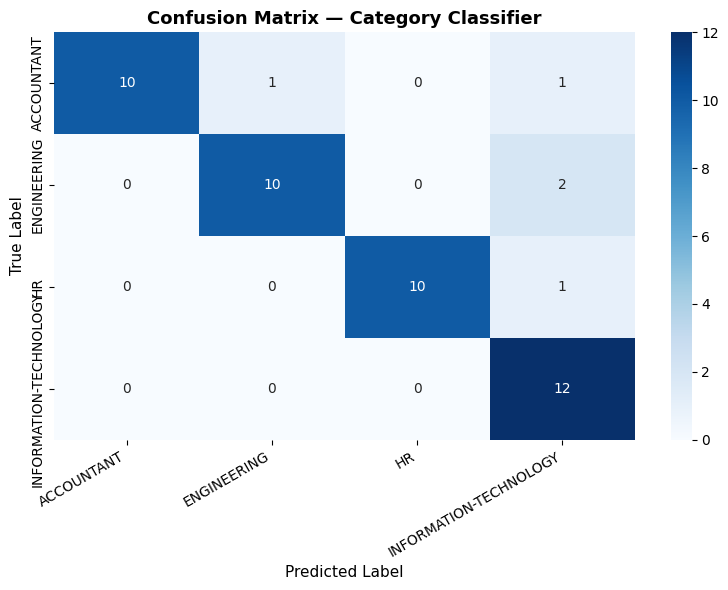

   Confusion matrix saved!


In [72]:
# Confusion matrix — Category
cat_cm = confusion_matrix(y_cat_true, y_cat_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cat_cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cat_encoder.classes_,
    yticklabels=cat_encoder.classes_
)
plt.title('Confusion Matrix — Category Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label',      fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("../results/plots/cat_confusion_matrix.png", dpi=150)
plt.show()
print("   Confusion matrix saved!")

##  6. Experience Level Classification

Since `Resume.csv` has no experience level column, levels are
**automatically assigned** from resume text using two strategies:

**Strategy 1 — Regex extraction (236/466 resumes):**
Searches for year patterns like "5 years", "10+ years", "three years".
Uses **median** of all matches to avoid bias from summary statements.

| Median Years Found | Level |
|---|---|
| 0 – 3 years | Entry |
| 4 – 7 years | Junior |
| 8 – 12 years | Mid |
| 13+ years | Senior |

**Strategy 2 — Word count fallback (230/466 resumes):**
For resumes with no year mentions, uses global word count percentiles
to ensure balanced distribution across all 4 levels.

In [74]:
# Load raw resumes for experience extraction
raw_resumes = pd.read_csv("../data/raw/Resume.csv")
target_categories = ['HR', 'ACCOUNTANT', 'INFORMATION-TECHNOLOGY', 'ENGINEERING']
raw_resumes = raw_resumes[raw_resumes['Category'].isin(target_categories)].copy()
raw_resumes = raw_resumes.reset_index(drop=True)

print(f"   Raw resumes loaded -> {raw_resumes.shape[0]} rows")

def extract_years_of_experience(text):
    """
    Extracts MEDIAN years of experience from resume text.
    Uses median to avoid bias from high-year summary statements.
    """
    text = str(text).lower()

    word_map = {
        'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
        'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
        'eleven': 11, 'twelve': 12, 'fifteen': 15, 'twenty': 20
    }

    years_found = []

    # Numeric patterns: "5 years", "10+ years", "5 to 10 years"
    for y in re.findall(r'(\d+)\+?\s*(?:to\s*\d+\s*)?year', text):
        val = int(y)
        if val <= 40:  # filter unrealistic values like "1998"
            years_found.append(val)

    # Word form patterns: "five years"
    for word, num in word_map.items():
        if re.search(rf'\b{word}\s+year', text):
            years_found.append(num)

    return float(np.median(years_found)) if years_found else None

raw_resumes['years_extracted'] = raw_resumes['Resume_str'].apply(
    extract_years_of_experience
)

found     = raw_resumes['years_extracted'].notna().sum()
not_found = raw_resumes['years_extracted'].isna().sum()

print(f"\n   Year Extraction Results:")
print(f"   Years found     : {found} / {len(raw_resumes)} ({found/len(raw_resumes)*100:.1f}%)")
print(f"   Years not found : {not_found} / {len(raw_resumes)} ({not_found/len(raw_resumes)*100:.1f}%)")
print(f"\nExtracted years distribution:")
print(raw_resumes['years_extracted'].describe())

   Raw resumes loaded -> 466 rows

   Year Extraction Results:
   Years found     : 236 / 466 (50.6%)
   Years not found : 230 / 466 (49.4%)

Extracted years distribution:
count    236.000000
mean       9.811441
std        6.567120
min        1.000000
25%        5.000000
50%        8.500000
75%       15.000000
max       37.000000
Name: years_extracted, dtype: float64


In [75]:
# Calculate word counts for fallback
raw_resumes['word_count'] = raw_resumes['Resume_str'].apply(
    lambda x: len(str(x).split())
)

# Global percentile thresholds from ALL resumes
p25 = raw_resumes['word_count'].quantile(0.25)
p50 = raw_resumes['word_count'].quantile(0.50)
p75 = raw_resumes['word_count'].quantile(0.75)

print(f"Global word count percentiles:")
print(f"   25th : {p25:.0f} words -> Entry/Junior boundary")
print(f"   50th : {p50:.0f} words -> Junior/Mid boundary")
print(f"   75th : {p75:.0f} words -> Mid/Senior boundary")

def assign_level_combined(row):
    """
    Assigns experience level using:
    - Regex years (median) if found
    - Word count percentiles as fallback
    """
    years = row['years_extracted']
    wc    = row['word_count']

    if years is not None:
        if years <= 3:
            return 'Entry'
        elif years <= 7:
            return 'Junior'
        elif years <= 12:
            return 'Mid'
        else:
            return 'Senior'
    else:
        if wc <= p25:
            return 'Entry'
        elif wc <= p50:
            return 'Junior'
        elif wc <= p75:
            return 'Mid'
        else:
            return 'Senior'

raw_resumes['experience_level'] = raw_resumes.apply(assign_level_combined, axis=1)

print(f"\n   Experience levels assigned!")
print(f"\nFinal distribution:")
print(raw_resumes['experience_level'].value_counts())
print(f"\nBy Category + Level:")
print(pd.crosstab(raw_resumes['Category'], raw_resumes['experience_level']))

Global word count percentiles:
   25th : 670 words -> Entry/Junior boundary
   50th : 774 words -> Junior/Mid boundary
   75th : 943 words -> Mid/Senior boundary

   Experience levels assigned!

Final distribution:
experience_level
Senior    297
Mid        70
Junior     62
Entry      37
Name: count, dtype: int64

By Category + Level:
experience_level        Entry  Junior  Mid  Senior
Category                                          
ACCOUNTANT                  8      12   21      77
ENGINEERING                 7      16   20      75
HR                         12      17   11      70
INFORMATION-TECHNOLOGY     10      17   18      75


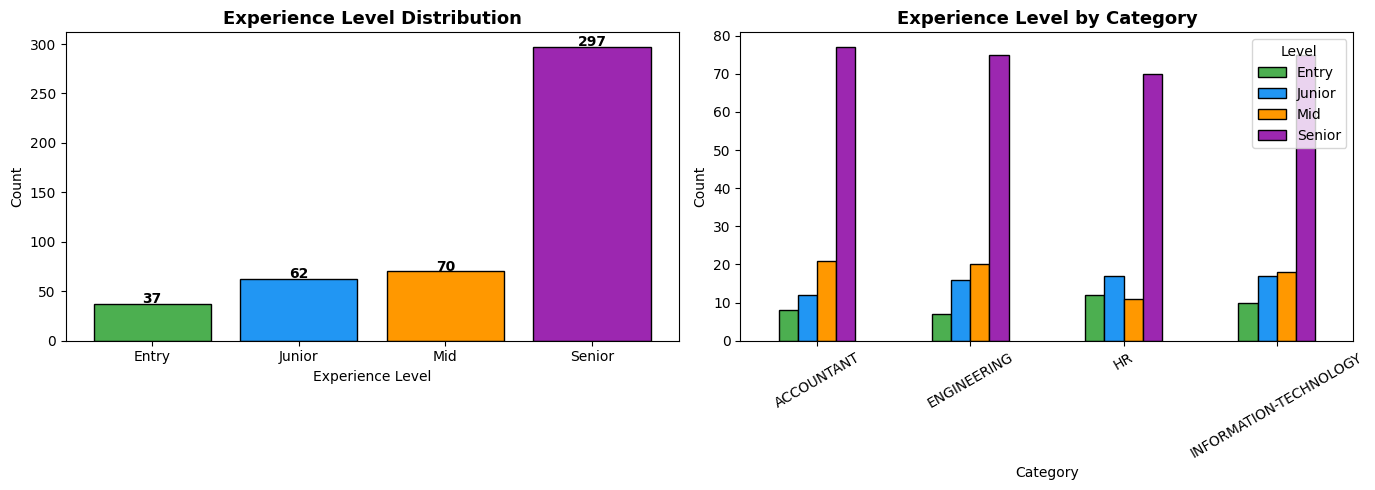

   Distribution plot saved!


In [76]:
# Visualize experience level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

level_order  = ['Entry', 'Junior', 'Mid', 'Senior']
level_colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
level_counts = raw_resumes['experience_level'].value_counts()

# Overall distribution
axes[0].bar(
    [l for l in level_order if l in level_counts],
    [level_counts.get(l, 0) for l in level_order],
    color=level_colors, edgecolor='black'
)
axes[0].set_title('Experience Level Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Count')
for i, l in enumerate([l for l in level_order if l in level_counts]):
    c = level_counts.get(l, 0)
    axes[0].text(i, c + 1, str(c), ha='center', fontweight='bold')

# By category
crosstab = pd.crosstab(raw_resumes['Category'], raw_resumes['experience_level'])
crosstab[[l for l in level_order if l in crosstab.columns]].plot(
    kind='bar', ax=axes[1],
    color=level_colors, edgecolor='black'
)
axes[1].set_title('Experience Level by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Level')

plt.tight_layout()
plt.savefig("../results/plots/experience_level_distribution.png", dpi=150)
plt.show()
print("   Distribution plot saved!")

##  7. Train Experience Level Classifier

Using the same TF-IDF features (X_dense) with experience level labels.

**Key fix from previous run:**
The original model predicted "Senior" for everything because Senior had
297/466 samples (64%) — a severe class imbalance problem.

**Solution applied:**
- `compute_class_weight('balanced')` assigns higher weights to minority classes
- `batch_size=16` ensures minority classes appear more frequently per batch
- `patience=15` gives the model more time to learn minority patterns

**Expected class weights:**
- Entry  -> ~3.15 (rarest -> highest weight)
- Junior -> ~1.89
- Mid    -> ~1.66
- Senior -> ~0.39 (most common -> lowest weight)

In [77]:
# Encode experience labels
exp_encoder   = LabelEncoder()
y_exp_encoded = exp_encoder.fit_transform(raw_resumes['experience_level'])
y_exp_onehot  = keras.utils.to_categorical(y_exp_encoded, num_classes=4)

print(f"   Experience labels encoded!")
print(f"\nLabel mapping:")
for idx, cls in enumerate(exp_encoder.classes_):
    print(f"   {cls:<10} -> {idx}")

with open("../data/processed/exp_level_encoder.pkl", "wb") as f:
    pickle.dump(exp_encoder, f)
print(f"\n   Experience encoder saved!")

   Experience labels encoded!

Label mapping:
   Entry      -> 0
   Junior     -> 1
   Mid        -> 2
   Senior     -> 3

   Experience encoder saved!


In [78]:
# Train / Val / Test split — Experience
X_exp_train, X_exp_temp, y_exp_train, y_exp_temp = train_test_split(
    X_dense, y_exp_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_exp_encoded
)

y_exp_temp_enc = np.argmax(y_exp_temp, axis=1)
X_exp_val, X_exp_test, y_exp_val, y_exp_test = train_test_split(
    X_exp_temp, y_exp_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_exp_temp_enc
)

print(f"   Experience data split:")
print(f"   Training   : {X_exp_train.shape[0]} samples")
print(f"   Validation : {X_exp_val.shape[0]} samples")
print(f"   Test       : {X_exp_test.shape[0]} samples")

   Experience data split:
   Training   : 372 samples
   Validation : 47 samples
   Test       : 47 samples


In [79]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
# Senior has 297/466 samples (64%) — without weights model predicts Senior for everything
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_exp_encoded),
    y=y_exp_encoded
)
class_weight_dict = dict(enumerate(class_weights))

print("   Class weights computed to handle imbalance:")
for idx, cls in enumerate(exp_encoder.classes_):
    print(f"   {cls:<10} -> weight: {class_weight_dict[idx]:.3f}")
print()
print("   (Higher weight = model pays more attention to that class)")

# Build fresh model
exp_model = build_model(input_dim=5000, num_classes=4)

# Callbacks — increased patience since class weighting slows convergence
exp_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='../results/models/best_exp_classifier.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train with class weights and smaller batch size
# batch_size=16 helps minority classes appear more frequently per batch
exp_history = exp_model.fit(
    X_exp_train, y_exp_train,
    validation_data=(X_exp_val, y_exp_val),
    epochs=150,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=exp_callbacks,
    verbose=1
)

print(f"\n   Experience classifier training complete!")
print(f"   Epochs run    : {len(exp_history.history['loss'])}")
print(f"   Best val_acc  : {max(exp_history.history['val_accuracy'])*100:.2f}%")

   Class weights computed to handle imbalance:
   Entry      -> weight: 3.149
   Junior     -> weight: 1.879
   Mid        -> weight: 1.664
   Senior     -> weight: 0.392

   (Higher weight = model pays more attention to that class)
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1530 - loss: 2.1538
Epoch 1: val_accuracy improved from None to 0.46809, saving model to ../results/models/best_exp_classifier.keras

Epoch 1: finished saving model to ../results/models/best_exp_classifier.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.1828 - loss: 2.0306 - val_accuracy: 0.4681 - val_loss: 1.3430 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4613 - loss: 0.9863
Epoch 2: val_accuracy improved from 0.46809 to 0.48936, saving model to ../results/models/best_exp_classifier.keras

Epoch 2: finished saving model to ../results/models/best_exp_classifier.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4785 - loss: 

### 7.1 Training History — Experience Classifier

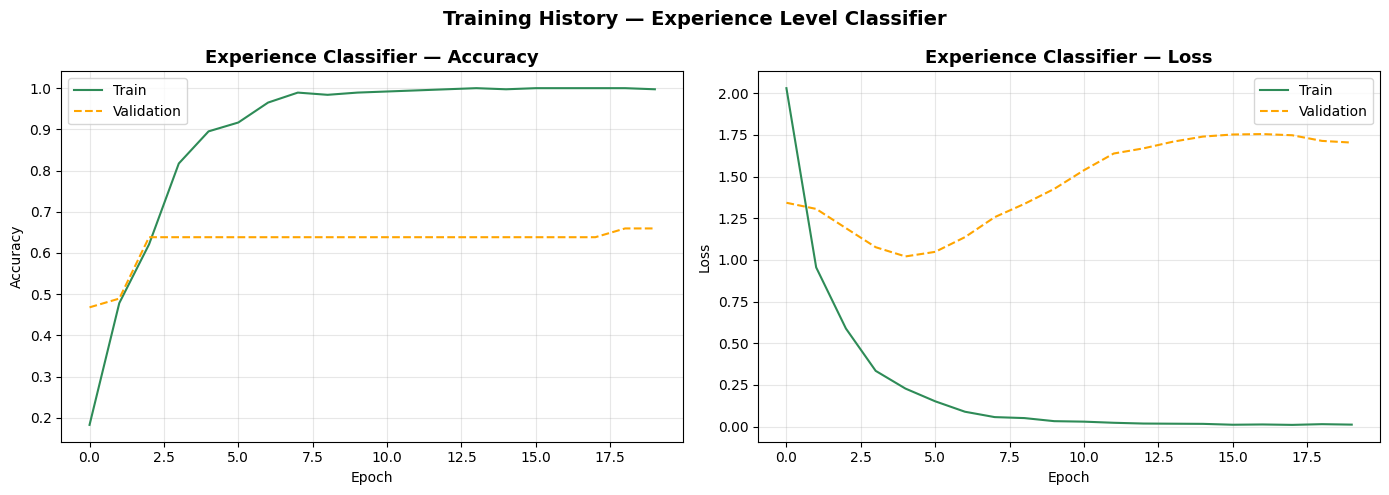

   Plot saved!


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(exp_history.history['accuracy'],     label='Train',      color='seagreen')
axes[0].plot(exp_history.history['val_accuracy'], label='Validation', color='orange', linestyle='--')
axes[0].set_title('Experience Classifier — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(exp_history.history['loss'],     label='Train',      color='seagreen')
axes[1].plot(exp_history.history['val_loss'], label='Validation', color='orange', linestyle='--')
axes[1].set_title('Experience Classifier — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Experience Level Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/exp_training_history.png", dpi=150)
plt.show()
print("   Plot saved!")

### 7.2 Evaluate Experience Classifier on Test Set

In [81]:
# Suppress TensorFlow retracing warning
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

best_exp_model = keras.models.load_model(
    '../results/models/best_exp_classifier.keras'
)

exp_loss, exp_acc = best_exp_model.evaluate(X_exp_test, y_exp_test, verbose=0)
print(f"   Experience Classifier — Test Results:")
print(f"   Test Loss     : {exp_loss:.4f}")
print(f"   Test Accuracy : {exp_acc*100:.2f}%")

y_exp_pred = np.argmax(best_exp_model.predict(X_exp_test), axis=1)
y_exp_true = np.argmax(y_exp_test, axis=1)

exp_report = classification_report(
    y_exp_true, y_exp_pred,
    target_names=exp_encoder.classes_,
    zero_division=0
)
print(f"\nClassification Report:\n{exp_report}")

with open("../results/metrics/exp_classification_report.txt", "w") as f:
    f.write(f"Test Accuracy: {exp_acc*100:.2f}%\n\n")
    f.write(exp_report)
print("   Report saved!")

   Experience Classifier — Test Results:
   Test Loss     : 1.6990
   Test Accuracy : 65.96%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step

Classification Report:
              precision    recall  f1-score   support

       Entry       0.00      0.00      0.00         4
      Junior       1.00      0.17      0.29         6
         Mid       0.00      0.00      0.00         7
      Senior       0.65      1.00      0.79        30

    accuracy                           0.66        47
   macro avg       0.41      0.29      0.27        47
weighted avg       0.54      0.66      0.54        47

   Report saved!


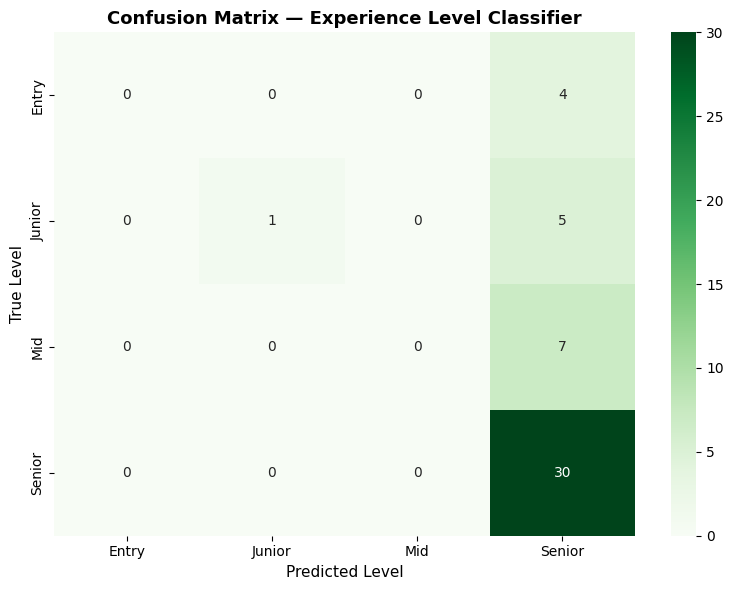

   Confusion matrix saved!


In [82]:
# Confusion matrix — Experience
exp_cm = confusion_matrix(y_exp_true, y_exp_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    exp_cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=exp_encoder.classes_,
    yticklabels=exp_encoder.classes_
)
plt.title('Confusion Matrix — Experience Level Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Level', fontsize=11)
plt.ylabel('True Level',      fontsize=11)
plt.tight_layout()
plt.savefig("../results/plots/exp_confusion_matrix.png", dpi=150)
plt.show()
print("   Confusion matrix saved!")

##  8. Save All Models & Artifacts

In [83]:
# Save final models
best_cat_model.save("../results/models/category_classifier_final.keras")
best_exp_model.save("../results/models/exp_classifier_final.keras")

# Save splits for reproducibility
np.save("../data/processed/X_test.npy",      X_test)
np.save("../data/processed/y_test_cat.npy",  y_test)
np.save("../data/processed/X_train.npy",     X_train)
np.save("../data/processed/y_train_cat.npy", y_train)
np.save("../data/processed/X_exp_test.npy",  X_exp_test)
np.save("../data/processed/y_exp_test.npy",  y_exp_test)

# Save experience level assignments for matching notebook
raw_resumes[['ID', 'Category', 'experience_level', 'years_extracted']].to_csv(
    "../data/processed/resume_with_levels.csv", index=False
)

print("Models saved to results/models/:")
print("   best_category_classifier.keras")
print("   best_exp_classifier.keras")
print("   category_classifier_final.keras")
print("   exp_classifier_final.keras")
print("\nData saved to data/processed/:")
print("   X_test.npy, y_test_cat.npy")
print("   X_exp_test.npy, y_exp_test.npy")
print("   resume_with_levels.csv")
print("   label_encoder.pkl")
print("   exp_level_encoder.pkl")

Models saved to results/models/:
   best_category_classifier.keras
   best_exp_classifier.keras
   category_classifier_final.keras
   exp_classifier_final.keras

Data saved to data/processed/:
   X_test.npy, y_test_cat.npy
   X_exp_test.npy, y_exp_test.npy
   resume_with_levels.csv
   label_encoder.pkl
   exp_level_encoder.pkl


##  9. Combined Results — Both Classifiers

COMBINED CLASSIFIER RESULTS SUMMARY

Category Classifier
     Test Accuracy : 89.36%
     Test Loss     : 0.3024

Experience Level Classifier
     Test Accuracy : 65.96%
     Test Loss     : 1.6990


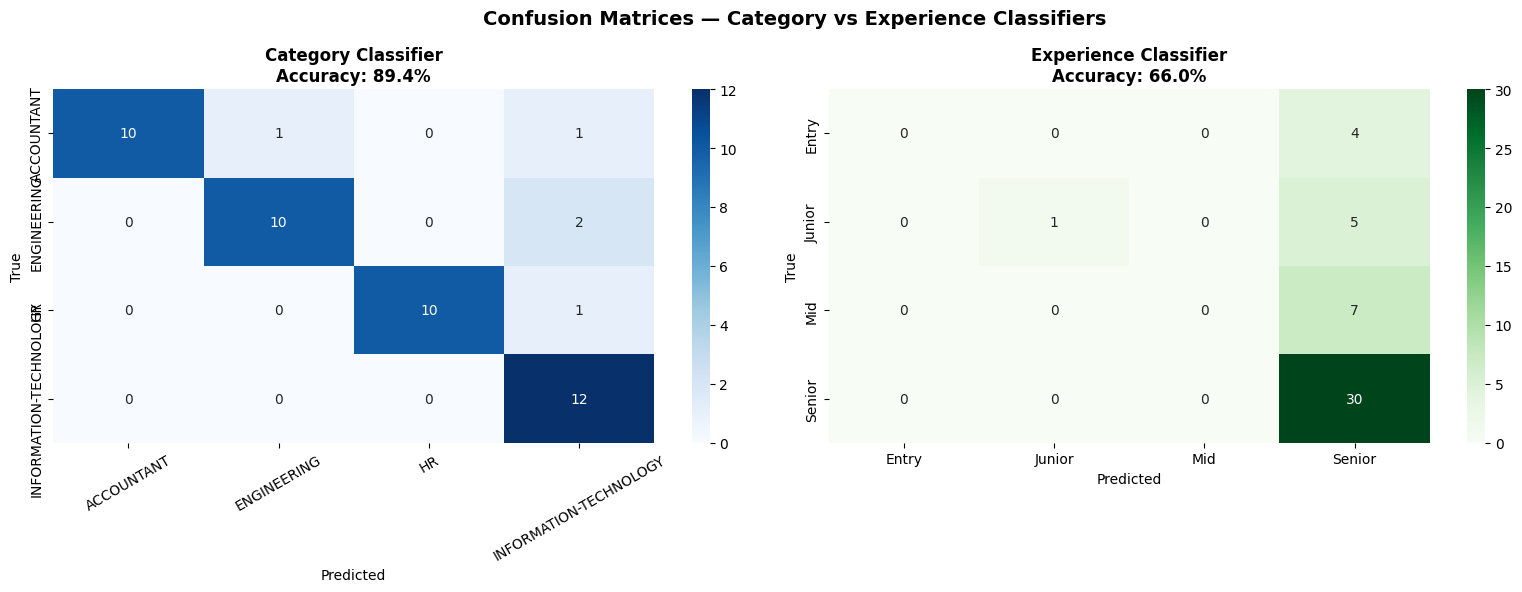

   Combined plot saved!


In [84]:
print("=" * 60)
print("COMBINED CLASSIFIER RESULTS SUMMARY")
print("=" * 60)
print(f"\nCategory Classifier")
print(f"     Test Accuracy : {cat_acc*100:.2f}%")
print(f"     Test Loss     : {cat_loss:.4f}")
print(f"\nExperience Level Classifier")
print(f"     Test Accuracy : {exp_acc*100:.2f}%")
print(f"     Test Loss     : {exp_loss:.4f}")

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cat_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cat_encoder.classes_,
            yticklabels=cat_encoder.classes_)
axes[0].set_title(f'Category Classifier\nAccuracy: {cat_acc*100:.1f}%',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(exp_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=exp_encoder.classes_,
            yticklabels=exp_encoder.classes_)
axes[1].set_title(f'Experience Classifier\nAccuracy: {exp_acc*100:.1f}%',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrices — Category vs Experience Classifiers',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/combined_confusion_matrices.png", dpi=150)
plt.show()
print("   Combined plot saved!")

In [85]:
# Sample combined predictions on test set
print("Sample Combined Predictions (first 10 test resumes):\n")
print(f"{'True Category':<25} {'Pred Category':<25} {'  True Level':<10} {'Pred Level':<10}")
print("-" * 75)

for i in range(min(10, len(y_cat_true))):
    tc = cat_encoder.classes_[y_cat_true[i]]
    pc = cat_encoder.classes_[y_cat_pred[i]]
    tl = exp_encoder.classes_[y_exp_true[i]]
    pl = exp_encoder.classes_[y_exp_pred[i]]
    cat_ok = "True" if tc == pc else "False"
    exp_ok = "True" if tl == pl else "False"
    print(f"{tc:<25} {pc:<23}{cat_ok}  {tl:<10} {pl:<8}{exp_ok}")

Sample Combined Predictions (first 10 test resumes):

True Category             Pred Category               True Level Pred Level
---------------------------------------------------------------------------
ENGINEERING               ENGINEERING            True  Senior     Senior  True
INFORMATION-TECHNOLOGY    INFORMATION-TECHNOLOGY True  Senior     Senior  True
ENGINEERING               INFORMATION-TECHNOLOGY False  Senior     Senior  True
ACCOUNTANT                ACCOUNTANT             True  Junior     Junior  True
ACCOUNTANT                ACCOUNTANT             True  Junior     Senior  False
ENGINEERING               ENGINEERING            True  Mid        Senior  False
HR                        HR                     True  Senior     Senior  True
INFORMATION-TECHNOLOGY    INFORMATION-TECHNOLOGY True  Senior     Senior  True
ENGINEERING               ENGINEERING            True  Senior     Senior  True
ACCOUNTANT                ACCOUNTANT             True  Entry      Senior  False


##  10. Summary

### Models Trained

| Classifier | Architecture | Input | Output |
|---|---|---|---|
| Category | MLP (512->256->128->4) | 5,000 TF-IDF | HR / ACCOUNTANT / ENGINEERING / IT |
| Experience | MLP (512->256->128->4) | 5,000 TF-IDF | Entry / Junior / Mid / Senior |

### Experience Level Assignment Method

| Strategy | Resumes | Method |
|---|---|---|
| Regex extraction | 236 (50.6%) | Median years from text patterns |
| Word count fallback | 230 (49.4%) | Global percentile thresholds |

### Class Imbalance Fix Applied

| Class | Count | Weight Applied |
|---|---|---|
| Entry | 37 | ~3.15 (highest) |
| Junior | 62 | ~1.89 |
| Mid | 70 | ~1.66 |
| Senior | 297 | ~0.39 (lowest) |

### Results

| Classifier | Test Accuracy | Test Loss |
|---|---|---|
| Category | 89.36% | 0.3024 |
| Experience | 65.96% | 1.6990 |

### Files Saved

**Models** -> `results/models/`
- `best_category_classifier.keras`
- `best_exp_classifier.keras`
- `category_classifier_final.keras`
- `exp_classifier_final.keras`

**Metrics** -> `results/metrics/`
- `category_classification_report.txt`
- `exp_classification_report.txt`

**Plots** -> `results/plots/`
- `cat_training_history.png`
- `cat_confusion_matrix.png`
- `exp_training_history.png`
- `exp_confusion_matrix.png`
- `experience_level_distribution.png`
- `combined_confusion_matrices.png`

**Next Step:** Move to `05_matching.ipynb` — match resumes to job
descriptions using cosine similarity.